Parse JSON IMC Results

In [1]:
import json
import pandas as pd
from io import StringIO

with open('../data/highest_result.json', 'r') as file:
    data = json.load(file)

activities_str = data['activitiesLog']

json_df = pd.read_csv(StringIO(activities_str), sep=';')

FileNotFoundError: [Errno 2] No such file or directory: '../data/highest_result.json'

Parse Log IMC Results

In [ ]:
import json
from io import StringIO
from pathlib import Path
import pandas as pd


def load_highest_result_log(path="../data/highest_result.log"):
    path = Path(path)

    with path.open("r", encoding="utf-8") as f:
        raw = json.load(f)

    print(raw.keys())  # helps confirm field names

    # IMC logs often store the activity table under "activitiesLog"
    # but sometimes the structure can differ, so we check safely.
    activities_text = raw.get("activitiesLog")

    if activities_text is None:
        raise KeyError(f"No 'activitiesLog' key found. Available keys: {list(raw.keys())}")

    activities = pd.read_csv(
        StringIO(activities_text),
        sep=";",
        na_values=["", "null", "None"],
    )

    trades = pd.DataFrame(raw.get("tradeHistory", []))
    sandbox = pd.DataFrame(raw.get("sandboxLogs", []))

    return {
        "submission_id": raw.get("submissionId"),
        "activities": activities,
        "trades": trades,
        "sandbox": sandbox,
        "raw": raw,
    }


parsed = load_highest_result_log()
activities_df = parsed["activities"]
trades_df = parsed["trades"]
sandbox_df = parsed["sandbox"]

dict_keys(['submissionId', 'activitiesLog', 'logs', 'tradeHistory'])


: 

Sort Products from Results Data

In [ ]:
activities_df

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,6,4998,19,NaN,NaN,5013,6,5014,19,NaN,NaN,5006.0,0.000000
1,-1,0,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.000000
2,-1,100,EMERALDS,9992,13,9990,30,NaN,NaN,10008,13,10010,30,NaN,NaN,10000.0,0.000000
3,-1,100,TOMATOES,5000,5,4998,23,NaN,NaN,5013,5,5014,23,NaN,NaN,5006.5,0.000000
4,-1,200,EMERALDS,9992,13,9990,21,NaN,NaN,10008,13,10010,21,NaN,NaN,10000.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,-1,199700,EMERALDS,9992,14,9990,28,NaN,NaN,10008,14,10010,28,NaN,NaN,10000.0,984.000000
3996,-1,199800,EMERALDS,9992,15,9990,27,NaN,NaN,10008,15,10010,27,NaN,NaN,10000.0,984.000000
3997,-1,199800,TOMATOES,4989,8,4987,25,NaN,NaN,5002,8,5003,25,NaN,NaN,4995.5,1315.808594
3998,-1,199900,TOMATOES,4990,10,4989,15,NaN,NaN,5003,10,5005,15,NaN,NaN,4996.5,1330.296875


: 

In [ ]:
trades_df

,timestamp,buyer,seller,symbol,currency,price,quantity
0,2900,SUBMISSION,,TOMATOES,XIRECS,4998.0,3
1,3300,SUBMISSION,,TOMATOES,XIRECS,4997.0,3
2,5900,,SUBMISSION,EMERALDS,XIRECS,10007.0,8
3,9100,SUBMISSION,,EMERALDS,XIRECS,10000.0,7
4,9700,SUBMISSION,,EMERALDS,XIRECS,9993.0,6
...,...,...,...,...,...,...,...
120,195200,SUBMISSION,,EMERALDS,XIRECS,10000.0,6
121,195500,SUBMISSION,,TOMATOES,XIRECS,4984.0,3
122,195900,,SUBMISSION,TOMATOES,XIRECS,4997.0,2
123,196800,,SUBMISSION,TOMATOES,XIRECS,4991.0,6


: 

In [ ]:
eme_price_res = activities_df[activities_df["product"] == "EMERALDS"].copy()
tom_price_res = activities_df[activities_df["product"] == "TOMATOES"].copy()

eme_trade_res = trades_df[trades_df["symbol"] == "EMERALDS"].copy()
tom_trade_res = trades_df[trades_df["symbol"] == "TOMATOES"].copy()

: 

IMC CSV Data to DataFrame

In [ ]:
day_1_prices = pd.read_csv("../data/prices_round_0_day_-1.csv", sep=";")
day_1_trades = pd.read_csv("../data/trades_round_0_day_-1.csv", sep=";")
day_2_prices = pd.read_csv("../data/prices_round_0_day_-2.csv", sep=";")
day_2_trades = pd.read_csv("../data/trades_round_0_day_-2.csv", sep=";")

: 

Sort Tomatoes Prices

In [ ]:
day_1_tom_prices = day_1_prices[day_1_prices["product"] == "TOMATOES"].copy()
day_2_tom_prices = day_2_prices[day_2_prices["product"] == "TOMATOES"].copy()

tom_prices = pd.concat([day_2_tom_prices, day_1_tom_prices])

: 

Sort Tomatoes Trades

In [ ]:
day_1_tom_trades = day_1_trades[day_1_trades["symbol"] == "TOMATOES"].copy()
day_2_tom_trades = day_2_trades[day_2_trades["symbol"] == "TOMATOES"].copy()
day_1_tom_trades["day"] = -1
day_2_tom_trades["day"] = -2

tom_trades = pd.concat([day_2_tom_trades, day_1_tom_trades])

: 

In [ ]:
tom_trades

,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,900,NaN,NaN,TOMATOES,XIRECS,5008.0,2,-2
1,1700,NaN,NaN,TOMATOES,XIRECS,5006.0,3,-2
3,4100,NaN,NaN,TOMATOES,XIRECS,5002.0,3,-2
5,6700,NaN,NaN,TOMATOES,XIRECS,4988.0,5,-2
6,7100,NaN,NaN,TOMATOES,XIRECS,5000.0,3,-2
...,...,...,...,...,...,...,...,...
622,979000,NaN,NaN,TOMATOES,XIRECS,4965.0,5,-1
624,982500,NaN,NaN,TOMATOES,XIRECS,4950.0,3,-1
627,985100,NaN,NaN,TOMATOES,XIRECS,4946.0,2,-1
629,993000,NaN,NaN,TOMATOES,XIRECS,4956.0,2,-1


: 

In [ ]:
day_1_tom_prices

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,5,4998,15,NaN,NaN,5013,5,5014,15,NaN,NaN,5006.0,0.0
3,-1,100,TOMATOES,5000,8,4998,21,NaN,NaN,5013,8,5014,21,NaN,NaN,5006.5,0.0
5,-1,200,TOMATOES,5000,10,4999,20,NaN,NaN,5013,10,5015,20,NaN,NaN,5006.5,0.0
6,-1,300,TOMATOES,5000,9,4999,21,NaN,NaN,5014,9,5015,21,NaN,NaN,5007.0,0.0
8,-1,400,TOMATOES,5000,5,4999,20,NaN,NaN,5014,5,5015,20,NaN,NaN,5007.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19990,-1,999500,TOMATOES,4955,5,4950,10,4948.0,23.0,4963,10,4964,23,NaN,NaN,4959.0,0.0
19993,-1,999600,TOMATOES,4955,5,4949,6,4948.0,18.0,4963,6,4964,18,NaN,NaN,4959.0,0.0
19994,-1,999700,TOMATOES,4950,10,4948,16,NaN,NaN,4963,10,4964,16,NaN,NaN,4956.5,0.0
19997,-1,999800,TOMATOES,4951,6,4949,18,NaN,NaN,4964,6,4965,18,NaN,NaN,4957.5,0.0


: 

In [ ]:
day_1_tom_trades

,timestamp,buyer,seller,symbol,currency,price,quantity,day
1,3400,NaN,NaN,TOMATOES,XIRECS,5009.0,2,-1
3,7000,NaN,NaN,TOMATOES,XIRECS,5010.0,4,-1
4,9600,NaN,NaN,TOMATOES,XIRECS,4999.0,5,-1
5,9900,NaN,NaN,TOMATOES,XIRECS,5000.0,4,-1
6,16400,NaN,NaN,TOMATOES,XIRECS,4996.0,2,-1
...,...,...,...,...,...,...,...,...
622,979000,NaN,NaN,TOMATOES,XIRECS,4965.0,5,-1
624,982500,NaN,NaN,TOMATOES,XIRECS,4950.0,3,-1
627,985100,NaN,NaN,TOMATOES,XIRECS,4946.0,2,-1
629,993000,NaN,NaN,TOMATOES,XIRECS,4956.0,2,-1


: 

Organize Emeralds Prices

In [ ]:
day_1_eme_prices = day_1_prices[day_1_prices["product"] == "EMERALDS"].copy()
day_2_eme_prices = day_2_prices[day_2_prices["product"] == "EMERALDS"].copy()

eme_prices = pd.concat([day_2_eme_prices, day_1_eme_prices])

: 

Sort Emeralds Trades

In [ ]:
day_1_eme_trades = day_1_trades[day_1_trades["symbol"] == "EMERALDS"].copy()
day_2_eme_trades = day_2_trades[day_2_trades["symbol"] == "EMERALDS"].copy()
day_1_eme_trades["day"] = -1
day_2_eme_trades["day"] = -2

eme_trades = pd.concat([day_2_eme_trades, day_1_eme_trades])

: 

: 

In [ ]:
eme_trades

,timestamp,buyer,seller,symbol,currency,price,quantity,day
2,4000,NaN,NaN,EMERALDS,XIRECS,10008.0,7,-2
4,5200,NaN,NaN,EMERALDS,XIRECS,9992.0,5,-2
7,10500,NaN,NaN,EMERALDS,XIRECS,10008.0,5,-2
9,11300,NaN,NaN,EMERALDS,XIRECS,9992.0,3,-2
16,22800,NaN,NaN,EMERALDS,XIRECS,10000.0,6,-2
...,...,...,...,...,...,...,...,...
620,973400,NaN,NaN,EMERALDS,XIRECS,10008.0,8,-1
623,979200,NaN,NaN,EMERALDS,XIRECS,10008.0,6,-1
625,982900,NaN,NaN,EMERALDS,XIRECS,10008.0,6,-1
626,983800,NaN,NaN,EMERALDS,XIRECS,10008.0,3,-1


: 

Unique Timestamps

In [ ]:
tom_trades["global_time"] = tom_trades["day"] * 1_000_000 + tom_trades["timestamp"]
tom_prices["global_time"] = tom_prices["day"] * 1_000_000 + tom_prices["timestamp"]

eme_trades["global_time"] = eme_trades["day"] * 1_000_000 + eme_trades["timestamp"]
eme_prices["global_time"] = eme_prices["day"] * 1_000_000 + eme_prices["timestamp"]

: 

Plotting Price as Line and Trades as Scatter (Sample Data)

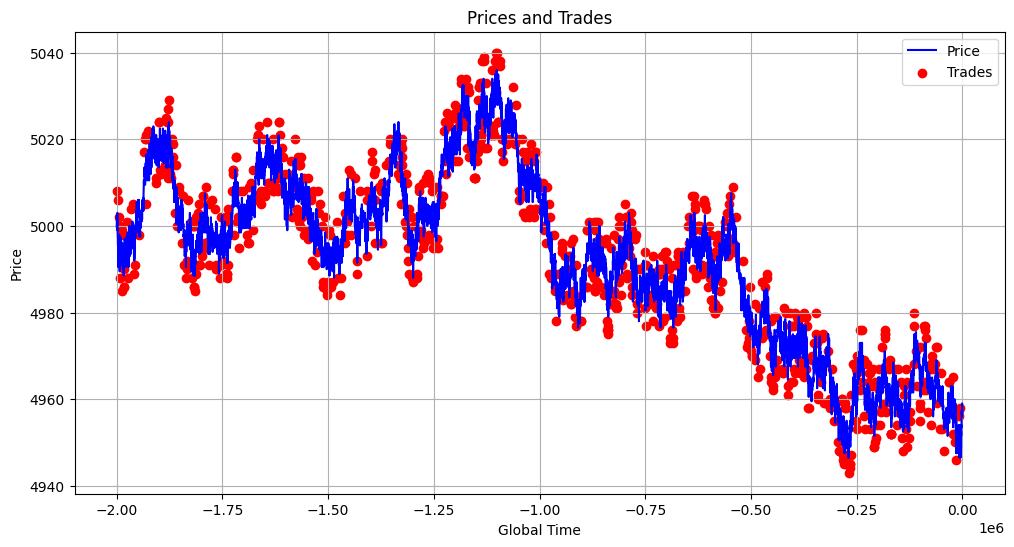

: 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# line for prices
plt.plot(tom_prices["global_time"], tom_prices["mid_price"], label="Price", color="b")

# scatter for trades
plt.scatter(tom_trades["global_time"], tom_trades["price"], label="Trades", color="red")

plt.xlabel("Global Time")
plt.ylabel("Price")
plt.title("Prices and Trades")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
eme_trades

,timestamp,buyer,seller,symbol,currency,price,quantity,day,global_time
2,4000,NaN,NaN,EMERALDS,XIRECS,10008.0,7,-2,-1996000
4,5200,NaN,NaN,EMERALDS,XIRECS,9992.0,5,-2,-1994800
7,10500,NaN,NaN,EMERALDS,XIRECS,10008.0,5,-2,-1989500
9,11300,NaN,NaN,EMERALDS,XIRECS,9992.0,3,-2,-1988700
16,22800,NaN,NaN,EMERALDS,XIRECS,10000.0,6,-2,-1977200
...,...,...,...,...,...,...,...,...,...
620,973400,NaN,NaN,EMERALDS,XIRECS,10008.0,8,-1,-26600
623,979200,NaN,NaN,EMERALDS,XIRECS,10008.0,6,-1,-20800
625,982900,NaN,NaN,EMERALDS,XIRECS,10008.0,6,-1,-17100
626,983800,NaN,NaN,EMERALDS,XIRECS,10008.0,3,-1,-16200


: 

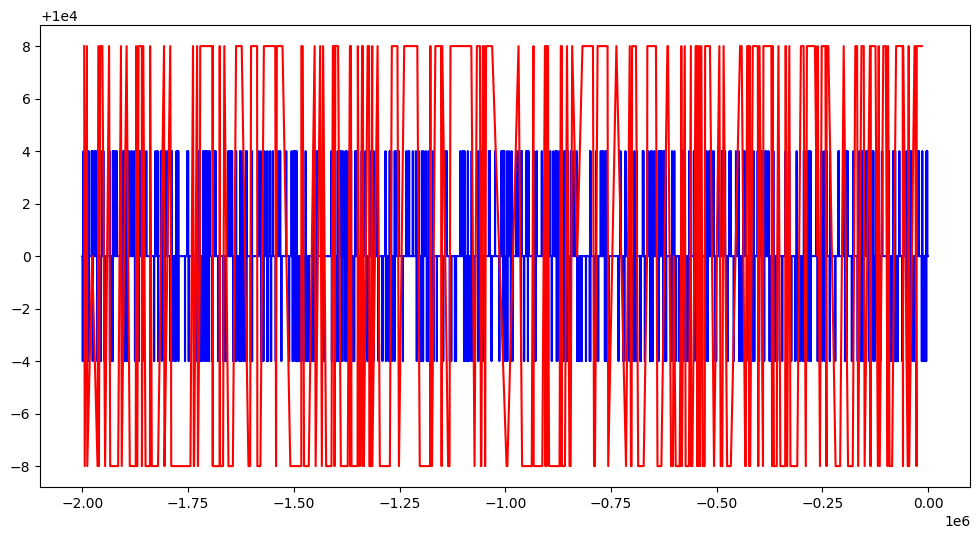

: 

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(eme_prices["global_time"], eme_prices["mid_price"], color="blue")

plt.plot(eme_trades["global_time"], eme_trades["price"], color='red')

plt.show()

Plotting Trades Against Prices (Results)

In [ ]:
activities_df

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,6,4998,19,NaN,NaN,5013,6,5014,19,NaN,NaN,5006.0,0.000000
1,-1,0,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.000000
2,-1,100,EMERALDS,9992,13,9990,30,NaN,NaN,10008,13,10010,30,NaN,NaN,10000.0,0.000000
3,-1,100,TOMATOES,5000,5,4998,23,NaN,NaN,5013,5,5014,23,NaN,NaN,5006.5,0.000000
4,-1,200,EMERALDS,9992,13,9990,21,NaN,NaN,10008,13,10010,21,NaN,NaN,10000.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,-1,199700,EMERALDS,9992,14,9990,28,NaN,NaN,10008,14,10010,28,NaN,NaN,10000.0,984.000000
3996,-1,199800,EMERALDS,9992,15,9990,27,NaN,NaN,10008,15,10010,27,NaN,NaN,10000.0,984.000000
3997,-1,199800,TOMATOES,4989,8,4987,25,NaN,NaN,5002,8,5003,25,NaN,NaN,4995.5,1315.808594
3998,-1,199900,TOMATOES,4990,10,4989,15,NaN,NaN,5003,10,5005,15,NaN,NaN,4996.5,1330.296875


: 

In [ ]:
trades_df

,timestamp,buyer,seller,symbol,currency,price,quantity
0,2900,SUBMISSION,,TOMATOES,XIRECS,4998.0,3
1,3300,SUBMISSION,,TOMATOES,XIRECS,4997.0,3
2,5900,,SUBMISSION,EMERALDS,XIRECS,10007.0,8
3,9100,SUBMISSION,,EMERALDS,XIRECS,10000.0,7
4,9700,SUBMISSION,,EMERALDS,XIRECS,9993.0,6
...,...,...,...,...,...,...,...
120,195200,SUBMISSION,,EMERALDS,XIRECS,10000.0,6
121,195500,SUBMISSION,,TOMATOES,XIRECS,4984.0,3
122,195900,,SUBMISSION,TOMATOES,XIRECS,4997.0,2
123,196800,,SUBMISSION,TOMATOES,XIRECS,4991.0,6


: 

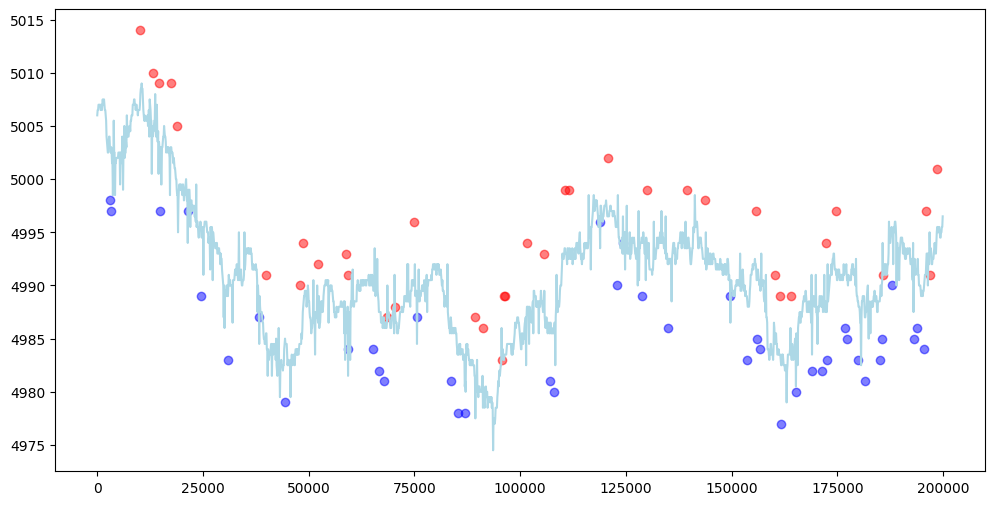

: 

In [ ]:
buy_trades = tom_trade_res[tom_trade_res["buyer"] == "SUBMISSION"]
sell_trades = tom_trade_res[tom_trade_res["seller"] == "SUBMISSION"]

plt.figure(figsize=(12, 6))
plt.plot(tom_price_res["timestamp"], tom_price_res["mid_price"], color="lightblue")

plt.scatter(buy_trades["timestamp"], buy_trades["price"], color="b", alpha=0.5)
plt.scatter(sell_trades["timestamp"], sell_trades["price"], color="r", alpha=0.5)
plt.show()